In [1]:
import numpy as np

import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


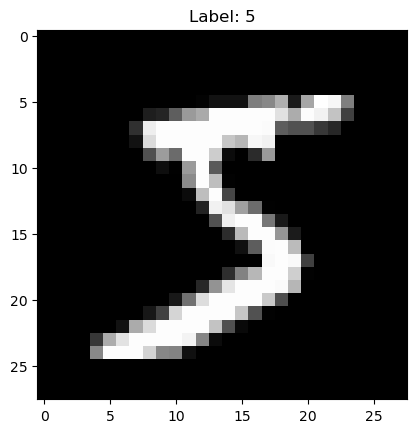

In [3]:
# Display the first training image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [4]:
# Print the raw pixel values of the first image
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [5]:
# Display the shapes of the dataset
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [6]:
# Reshape the image data into 2D vectors (flatten 28x28 into 784)
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255

In [7]:
# One-hot encode the labels
num_classes = 10
y_train = np.eye(num_classes)[y_train]
y_test = np.eye(num_classes)[y_test]

In [8]:
# Define the model
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

In [12]:
# Train the model
batch_size = 128
epochs = 20

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9213 - loss: 0.2554 - val_accuracy: 0.9657 - val_loss: 0.1091
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9683 - loss: 0.1045 - val_accuracy: 0.9727 - val_loss: 0.0894
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9767 - loss: 0.0754 - val_accuracy: 0.9782 - val_loss: 0.0746
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9818 - loss: 0.0583 - val_accuracy: 0.9782 - val_loss: 0.0734
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9849 - loss: 0.0496 - val_accuracy: 0.9813 - val_loss: 0.0615
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9873 - loss: 0.0404 - val_accuracy: 0.9821 - val_loss: 0.0611
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9894 - loss: 0.0344 - val_accuracy: 0.9793 - val_loss: 0.0714
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9899 - loss: 0.0291 - val_accuracy: 0.

### Model Prediction Example

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


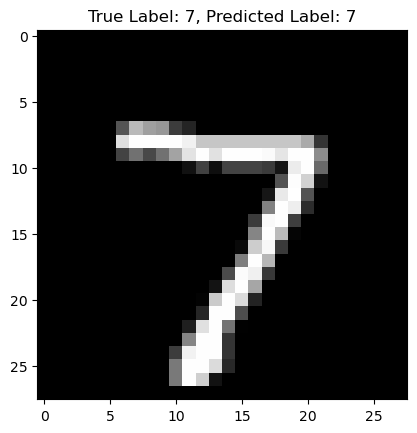

Raw prediction probabilities: [5.1000797e-17 6.2881768e-14 1.8036859e-15 2.2543176e-11 1.8945018e-19
 1.1360780e-16 9.9278330e-21 1.0000000e+00 1.5806070e-16 1.8748940e-10]


In [13]:
# Select an image from the test set (e.g., the first image)
image_index = 0
input_image = x_test[image_index]
true_label_one_hot = y_test[image_index]

true_label = np.argmax(true_label_one_hot)

# Reshape the input image for display (28x28) and prediction (1, 784)
image_for_display = input_image.reshape(28, 28)
image_for_prediction = np.expand_dims(input_image, axis=0)

# Predict the digit using the trained model
predictions = model.predict(image_for_prediction)
predicted_label = np.argmax(predictions[0])

plt.imshow(image_for_display, cmap='gray')
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label}")
plt.show()

print(f"Raw prediction probabilities: {predictions[0]}")

In [14]:
# Evaluate the model
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.07803808897733688
Test accuracy: 0.9857000112533569
